# Univariate Return Distribution and GARCH Analysis
This notebook models each asset independently using:
- Univariate return distributions: Normal, Student-t, and Stable
- Time dependence: auto-selected GARCH with Student-t innovations


## Data & Setup


In [5]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import altair as alt

from scipy.stats import norm, t, levy_stable, probplot
from statsmodels.graphics.tsaplots import plot_acf
from arch import arch_model

plt.style.use('seaborn-v0_8-whitegrid')

# ===== Config =====
ALPHA = 0.05
# Significance level for tail-risk context; used conceptually in result interpretation text (cell 11).

DIST_QQ_REF = 't'
# Reference distribution for the right-side QQ plot in plot_distribution_diagnostics() (code cell 6).

GARCH_ORDER = (1, 1)
# (p, q) order passed into arch_model(...) inside fit_garch_11() (code cell 8).

GARCH_DIST = 't'
# Innovation distribution passed into arch_model(..., dist=GARCH_DIST) in fit_garch_11() (code cell 8).

PLOT_BINS = 20
# Histogram bin count used in plot_distribution_diagnostics() (code cell 6)
# and plot_garch_diagnostics() (code cell 9).

PDF_GRID_POINTS = 400
# Number of x-grid points for fitted PDF curves in plot_distribution_diagnostics() (code cell 6).

STD_RESID_ACF_MAX_LAGS = 20
# Upper bound for lags in squared standardized-residual ACF in plot_garch_diagnostics() (code cell 9).


In [2]:
ret_df = pd.read_csv('../data/processed_returns.csv', index_col=0, parse_dates=True)
assets = [c for c in ret_df.columns if pd.api.types.is_numeric_dtype(ret_df[c])]

print(f'Shape: {ret_df.shape}')
print('Assets:', assets)
ret_df.head()


Shape: (96, 4)
Assets: ['SPY', 'AGG', 'PE', 'NPI']


,SPY,AGG,PE,NPI
Date,,,,
2000-03-31,2.643259,NaN,7.000000,3.200000
2000-06-30,-3.159936,NaN,-9.985944,2.188084
2000-09-30,-0.891586,NaN,-22.221572,2.088084
2000-12-31,-8.379575,NaN,-10.050315,1.482126
2001-03-31,-10.811495,NaN,1.353127,-3.727454


# Summary Statistics

In [6]:
def summary_statistics(df: pd.DataFrame, assets: list[str]) -> pd.DataFrame:
    stats = []
    for asset in assets:
        series = df[asset].dropna()
        stats.append({
            'Asset': asset,
            'Count': len(series),
            'Mean': series.mean(),
            'Min': series.min(),
            'Max': series.max(),
            'Std Dev': series.std(),
            'Skewness': series.skew(),
            'Excess Kurtosis': series.kurtosis() - 3
        })
    return pd.DataFrame(stats)

summary_df = summary_statistics(ret_df, assets)
summary_df

,Asset,Count,Mean,Min,Max,Std Dev,Skewness,Excess Kurtosis
0,SPY,96,2.046159,-21.568638,20.161739,8.332529,-0.700630,-2.612748
1,AGG,81,0.768950,-5.845777,7.381536,2.303305,-0.194328,-1.915968
2,PE,96,2.669414,-33.178141,52.737521,12.592994,0.065140,0.615419
3,NPI,96,1.658198,-37.917060,26.333648,9.329962,-1.420929,1.893991


In [22]:
def plot_extreme_returns_altair(summary_df):
    df = summary_df.copy()
    df['Predicted'] = df["Mean"] + (df['Std Dev'] * np.sqrt(2 * np.log(df['Count'])))
    df['Min'] = -df['Min']

    melted = pd.melt(
        df[['Asset', 'Predicted', 'Min']],
        id_vars='Asset',
        value_vars=['Predicted', 'Min'],
        var_name='Series',
        value_name='Return (%)'
    )
    
    # Use Unicode equivalents for math symbols
    label_formula = "μ + σ√(2 ln n)"
    subtitle_text = f"E[min(Xi)] ≈ μ + σ√(2 ln n)"

    melted['Series'] = melted['Series'].map({
        'Predicted': "Predicted Worst Return",
        'Min': 'Historical Worse Return'
    })

    chart = alt.Chart(melted).mark_bar().encode(
        x=alt.X('Asset:N', axis=alt.Axis(labelAngle=0, title=None)),
        xOffset='Series:N',
        y=alt.Y('Return (%):Q', title='Quarterly Return (%)'),
        color=alt.Color('Series:N', scale=alt.Scale(
            range=['#5B9BD5', '#C9A84C']
        ), legend=alt.Legend(orient='top-left', title=None)),
        tooltip=['Asset', 'Series', alt.Tooltip('Return (%):Q', format='.1f')]
    ).properties(
        title=alt.TitleParams(
            text='Predicted vs Historical Worst-Case Returns',
            subtitle=subtitle_text,
        ),
        width=520, height=360
    )

    text = chart.mark_text(
        dy=-5, # Move text above the bar (negative dy)
        fontSize=10,
        baseline='bottom'
    ).encode(
        text=alt.Text('Return (%):Q', format='.1f')
    )

    return (chart + text)

plot_extreme_returns_altair(summary_df)

alt.LayerChart(...)

## Univariate Distribution Modeling
We fit Normal, Student-t, and Stable distributions to each asset's return series and compare by AIC (tie-breaker: BIC).


In [4]:
def information_criteria(loglik, n_obs, n_params):
    aic = 2 * n_params - 2 * loglik
    bic = np.log(n_obs) * n_params - 2 * loglik
    return aic, bic


def fit_distribution_models(series):
    x = series.dropna().astype(float).values
    n = len(x)
    records = []

    # Normal
    norm_params = norm.fit(x)
    ll_norm = np.sum(norm.logpdf(x, *norm_params))
    aic_norm, bic_norm = information_criteria(ll_norm, n, 2)
    records.append({
        'Model': 'normal',
        'LogLik': ll_norm,
        'AIC': aic_norm,
        'BIC': bic_norm,
        'Params': norm_params,
        'NumParams': 2,
    })

    # Student-t
    t_params = t.fit(x)
    ll_t = np.sum(t.logpdf(x, *t_params))
    aic_t, bic_t = information_criteria(ll_t, n, 3)
    records.append({
        'Model': 't',
        'LogLik': ll_t,
        'AIC': aic_t,
        'BIC': bic_t,
        'Params': t_params,
        'NumParams': 3,
    })

    # Stable
    try:
        stable_params = levy_stable.fit(x)
        ll_stable = np.sum(levy_stable.logpdf(x, *stable_params))
        aic_stable, bic_stable = information_criteria(ll_stable, n, 4)
        records.append({
            'Model': 'stable',
            'LogLik': ll_stable,
            'AIC': aic_stable,
            'BIC': bic_stable,
            'Params': stable_params,
            'NumParams': 4,
        })
    except Exception as err:
        print(f'[WARN] Stable fit failed for {series.name}: {type(err).__name__}: {err}')
        records.append({
            'Model': 'stable',
            'LogLik': np.nan,
            'AIC': np.inf,
            'BIC': np.inf,
            'Params': None,
            'NumParams': 4,
        })

    dist_df = pd.DataFrame(records).sort_values(['AIC', 'BIC']).reset_index(drop=True)
    return x, dist_df


def build_distribution_summary(ret_df, assets):
    all_dist_details = {}
    summary_rows = []

    for asset in assets:
        x, dist_df = fit_distribution_models(ret_df[asset])
        all_dist_details[asset] = {'data': x, 'table': dist_df}

        best = dist_df.iloc[0]
        summary_rows.append({
            'Asset': asset,
            'N': len(x),
            'BestModel': best['Model'],
            'BestAIC': best['AIC'],
            'BestBIC': best['BIC'],
            'BestLogLik': best['LogLik'],
        })

    summary_dist = pd.DataFrame(summary_rows).sort_values('Asset').reset_index(drop=True)
    return all_dist_details, summary_dist


all_dist_details, summary_dist = build_distribution_summary(ret_df, assets)
summary_dist


,Asset,N,BestModel,BestAIC,BestBIC,BestLogLik
0,AGG,81,t,367.126566,374.309914,-180.563283
1,NPI,96,t,633.535993,641.229037,-313.767996
2,PE,96,t,719.847923,727.540967,-356.923961
3,SPY,96,stable,680.727967,690.985360,-336.363983


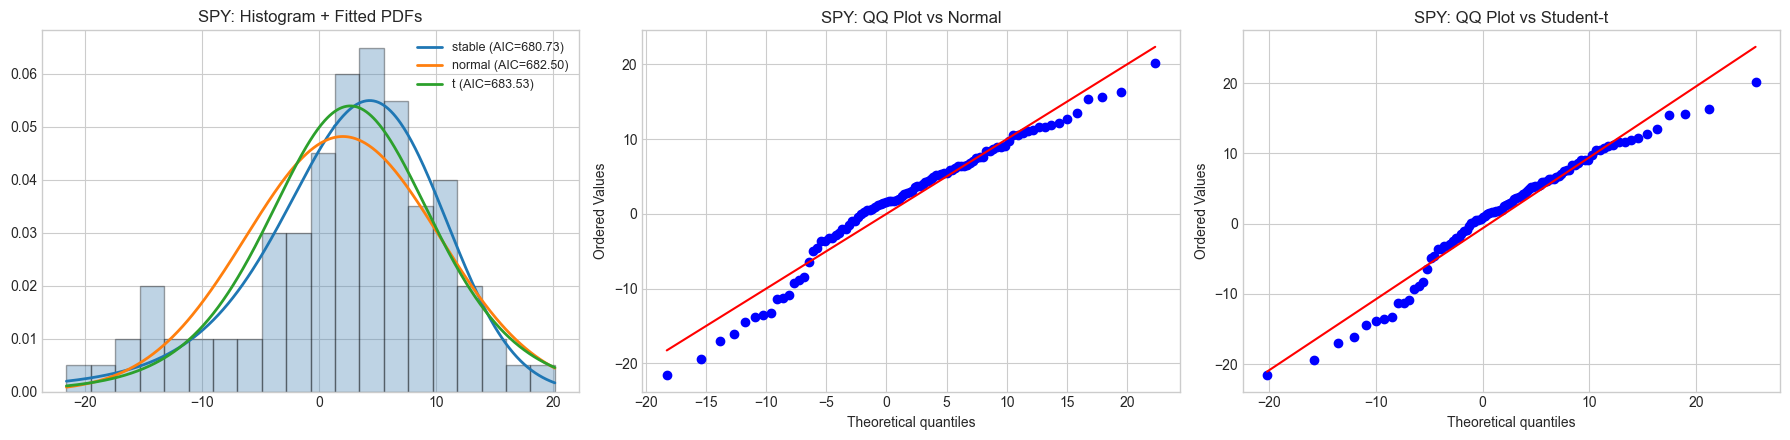

--- SPY distribution fit table ---


,Model,LogLik,AIC,BIC
0,stable,-336.363983,680.727967,690.985360
1,normal,-339.251510,682.503019,687.631716
2,t,-338.766359,683.532718,691.225763


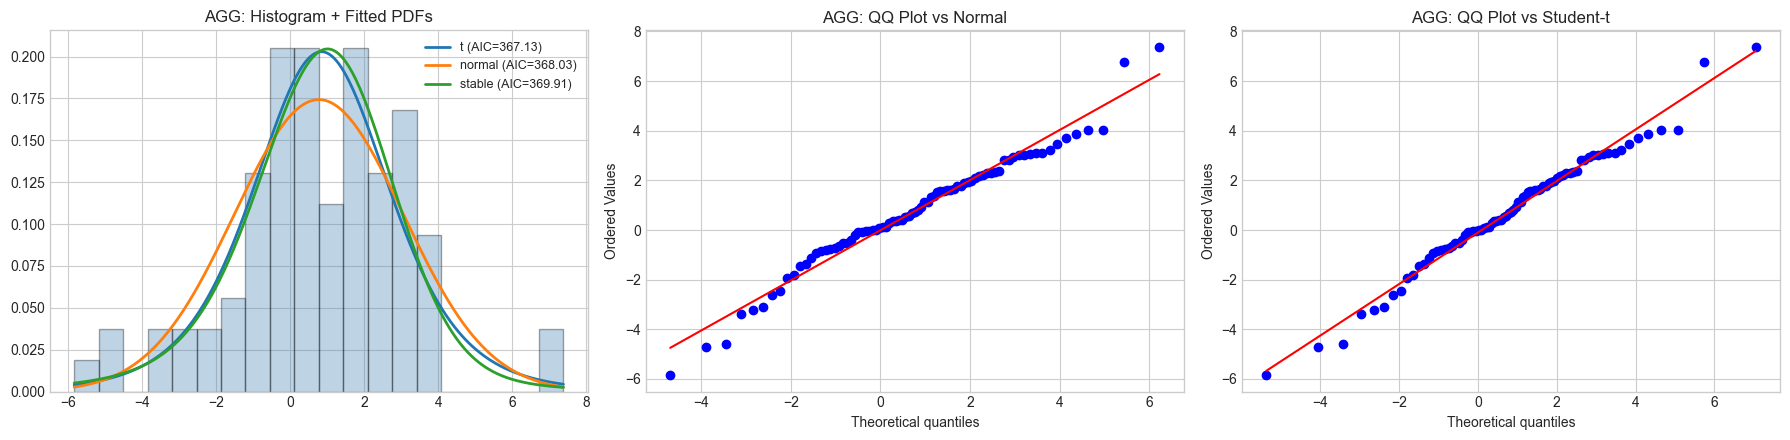

--- AGG distribution fit table ---


,Model,LogLik,AIC,BIC
0,t,-180.563283,367.126566,374.309914
1,normal,-182.012848,368.025697,372.814595
2,stable,-180.953191,369.906382,379.484178


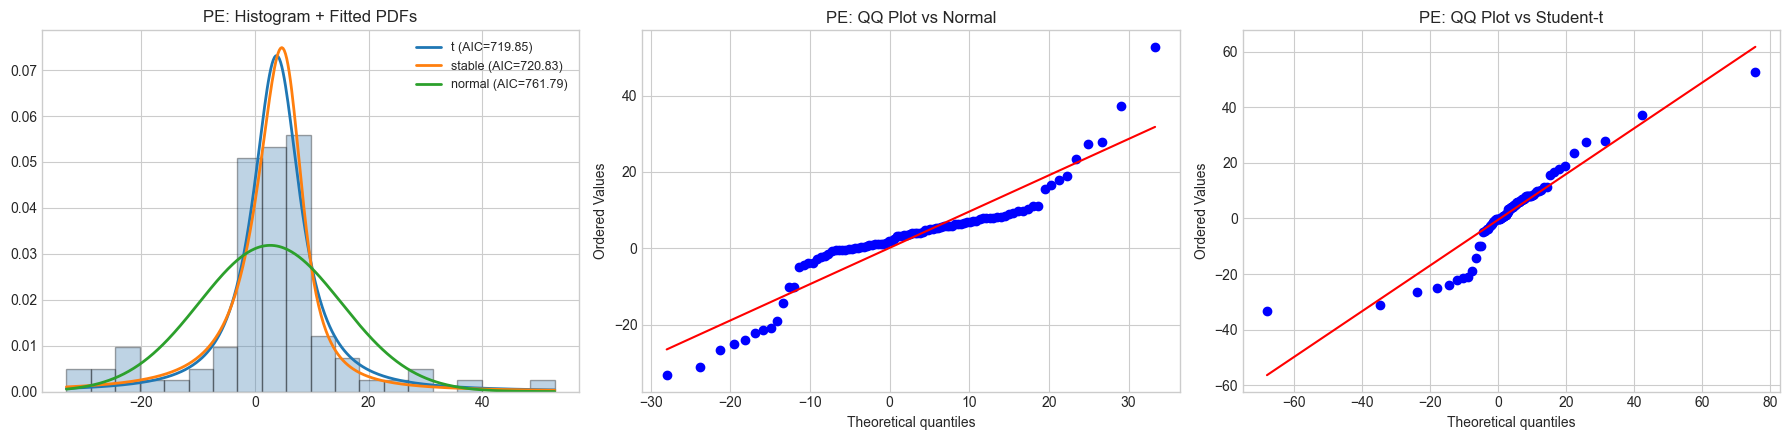

--- PE distribution fit table ---


,Model,LogLik,AIC,BIC
0,t,-356.923961,719.847923,727.540967
1,stable,-356.413217,720.826434,731.083827
2,normal,-378.896973,761.793947,766.922643


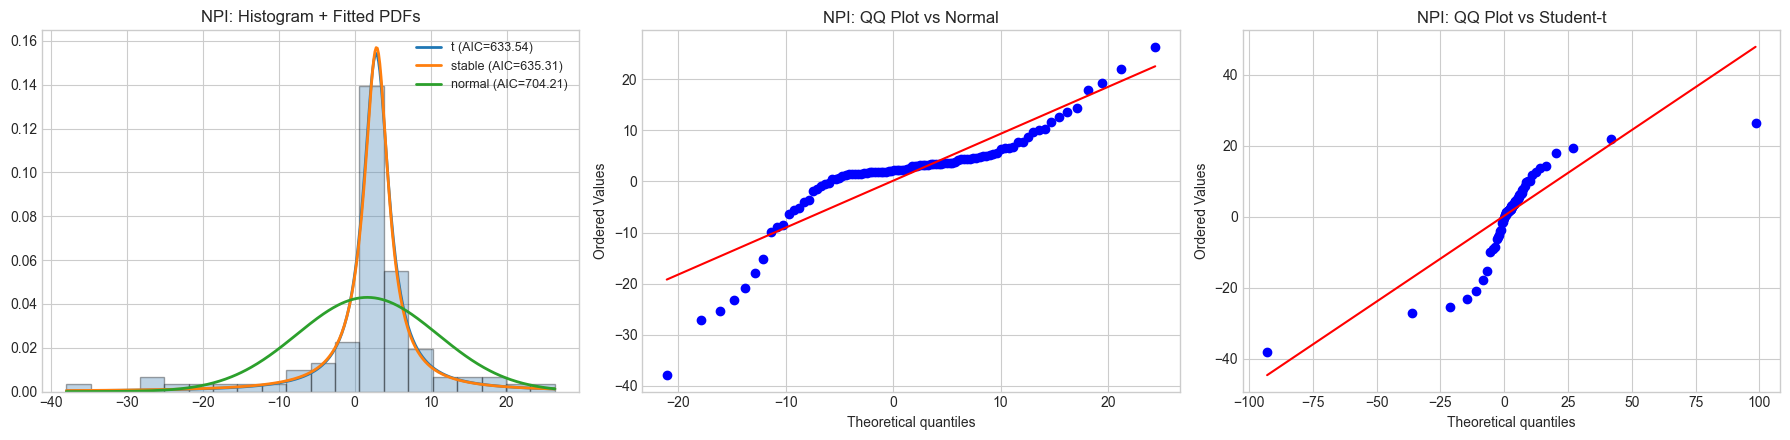

--- NPI distribution fit table ---


,Model,LogLik,AIC,BIC
0,t,-313.767996,633.535993,641.229037
1,stable,-313.655976,635.311952,645.569344
2,normal,-350.105646,704.211293,709.339989


In [5]:
def plot_distribution_diagnostics(assets, all_dist_details):
    for asset in assets:
        x = all_dist_details[asset]['data']
        dist_df = all_dist_details[asset]['table']

        fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

        # Histogram + fitted PDFs
        grid = np.linspace(np.nanmin(x), np.nanmax(x), PDF_GRID_POINTS)
        axes[0].hist(x, bins=PLOT_BINS, density=True, alpha=0.35, color='steelblue', edgecolor='black')

        for _, row in dist_df.iterrows():
            model = row['Model']
            params = row['Params']
            if params is None:
                continue

            if model == 'normal':
                pdf = norm.pdf(grid, *params)
            elif model == 't':
                pdf = t.pdf(grid, *params)
            else:
                pdf = levy_stable.pdf(grid, *params)

            axes[0].plot(grid, pdf, linewidth=2, label=f"{model} (AIC={row['AIC']:.2f})")

        axes[0].set_title(f'{asset}: Histogram + Fitted PDFs')
        axes[0].legend(fontsize=9)

        # QQ plot vs Normal
        probplot(x, dist='norm', sparams=norm.fit(x), plot=axes[1])
        axes[1].set_title(f'{asset}: QQ Plot vs Normal')

        # QQ plot vs Student-t
        t_params = dist_df.loc[dist_df['Model'] == DIST_QQ_REF, 'Params'].iloc[0]
        probplot(x, dist=t, sparams=t_params, plot=axes[2])
        axes[2].set_title(f'{asset}: QQ Plot vs Student-t')

        plt.tight_layout()
        plt.show()

        print(f'--- {asset} distribution fit table ---')
        display(dist_df[['Model', 'LogLik', 'AIC', 'BIC']])


plot_distribution_diagnostics(assets, all_dist_details)


## Time Dependence (Auto-Selected GARCH)
Candidate models: GARCH(1,1), GARCH(1,2), GARCH(2,1), GARCH(2,2), all with constant mean and Student-t innovations. Selection criterion: lowest BIC.


In [6]:
def fit_garch_11(series):
    s = series.dropna().astype(float)
    p, q = GARCH_ORDER

    am = arch_model(
        s,
        mean='Constant',
        vol='GARCH',
        p=p,
        q=q,
        dist=GARCH_DIST,
        rescale=False,
    )
    res = am.fit(disp='off')

    params = res.params
    alpha_sum = sum(v for k, v in params.items() if str(k).startswith('alpha['))
    beta_sum = sum(v for k, v in params.items() if str(k).startswith('beta['))

    meta = {
        'P': p,
        'Q': q,
        'AIC': res.aic,
        'BIC': res.bic,
        'LogLik': res.loglikelihood,
        'Omega': params.get('omega', np.nan),
        'Nu': params.get('nu', np.nan),
        'AlphaSum': alpha_sum,
        'BetaSum': beta_sum,
        'Persistence': alpha_sum + beta_sum,
    }

    return res, meta


def build_garch_summary(ret_df, assets):
    all_garch = {}
    garch_rows = []

    for asset in assets:
        try:
            res, meta = fit_garch_11(ret_df[asset])
        except Exception as err:
            print(f'[WARN] GARCH(1,1) fit failed for {asset}: {type(err).__name__}: {err}')
            continue

        all_garch[asset] = {'res': res, 'meta': meta}
        garch_rows.append({
            'Asset': asset,
            'SelectedModel': f"GARCH({meta['P']},{meta['Q']})",
            'AIC': meta['AIC'],
            'BIC': meta['BIC'],
            'LogLik': meta['LogLik'],
            'Omega': meta['Omega'],
            'Nu': meta['Nu'],
            'AlphaSum': meta['AlphaSum'],
            'BetaSum': meta['BetaSum'],
            'Persistence': meta['Persistence'],
        })

    summary_garch = pd.DataFrame(garch_rows).sort_values('Asset').reset_index(drop=True)
    return all_garch, summary_garch


all_garch, summary_garch = build_garch_summary(ret_df, assets)
summary_garch


,Asset,SelectedModel,AIC,BIC,LogLik,Omega,Nu,AlphaSum,BetaSum,Persistence
0,AGG,"GARCH(1,1)",367.054978,379.027223,-178.527489,0.482873,7.765296,0.105399,0.819828,0.925227
1,NPI,"GARCH(1,1)",589.290380,602.112121,-289.645190,3.440585,3.845543,1.000000,0.000000,1.000000
2,PE,"GARCH(1,1)",676.728773,689.550514,-333.364386,10.343877,4.524536,0.772573,0.227427,1.000000
3,SPY,"GARCH(1,1)",674.673324,687.495065,-332.336662,6.264052,5.625004,0.405781,0.594219,1.000000


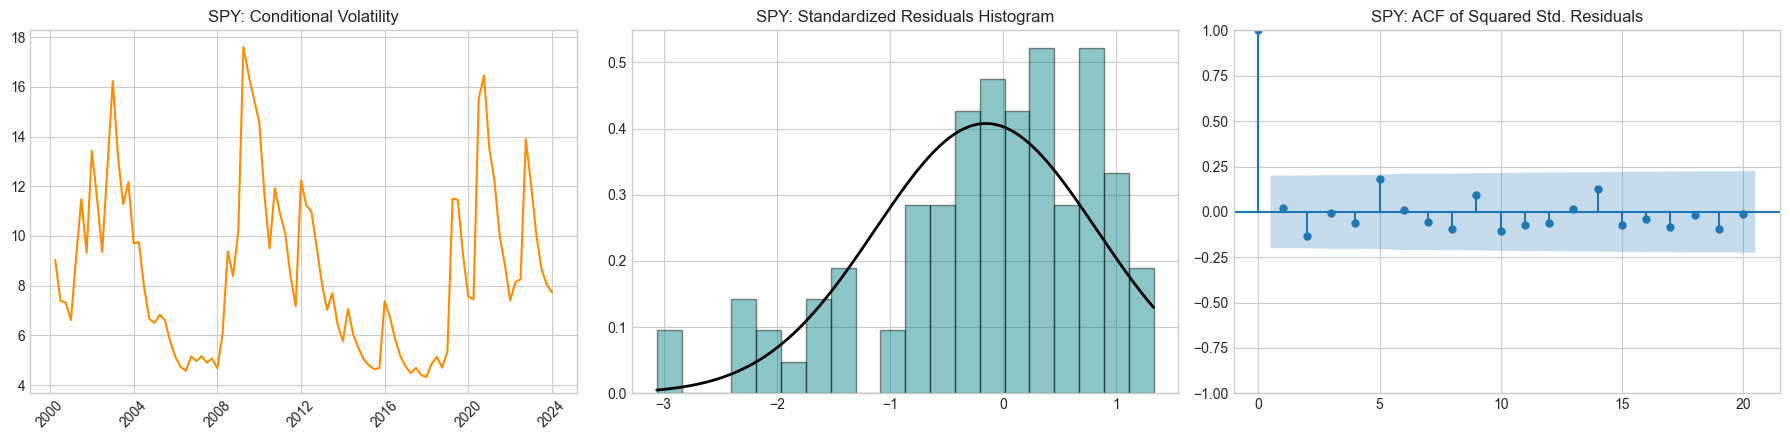

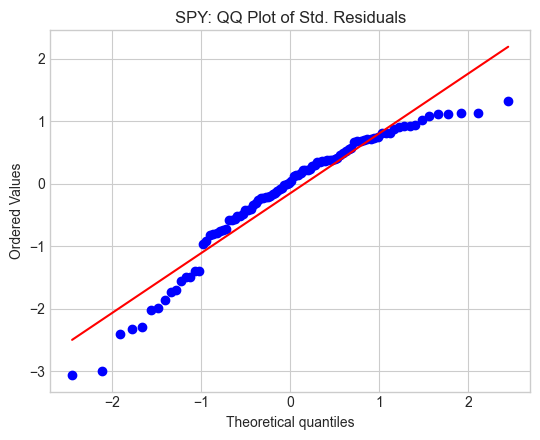

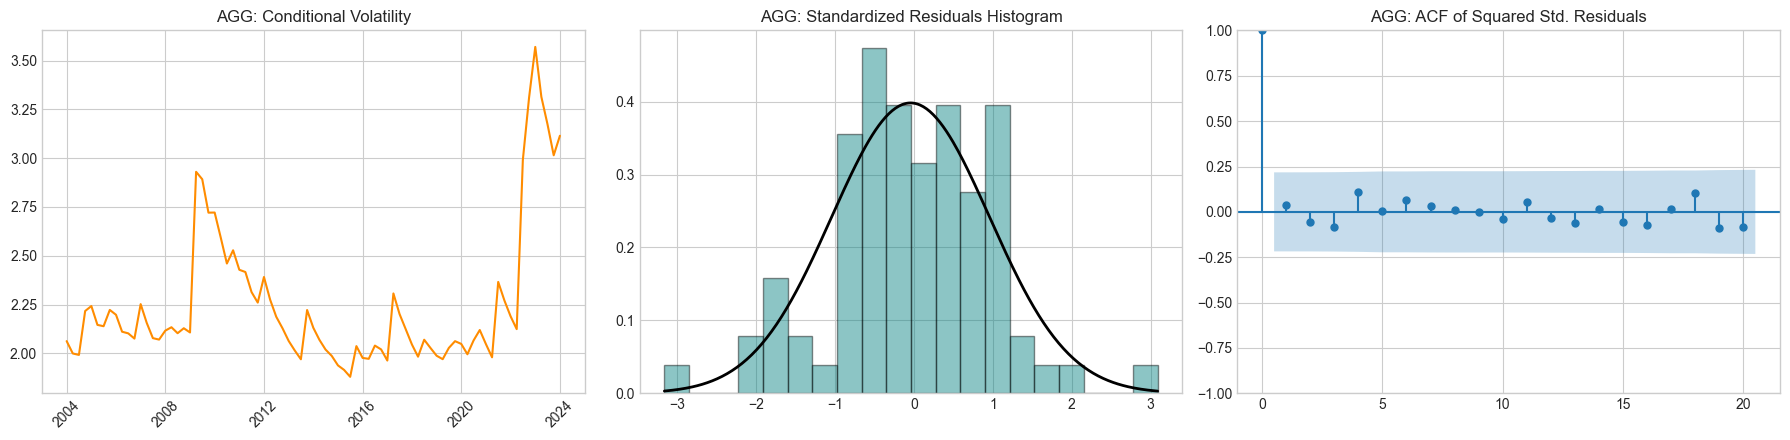

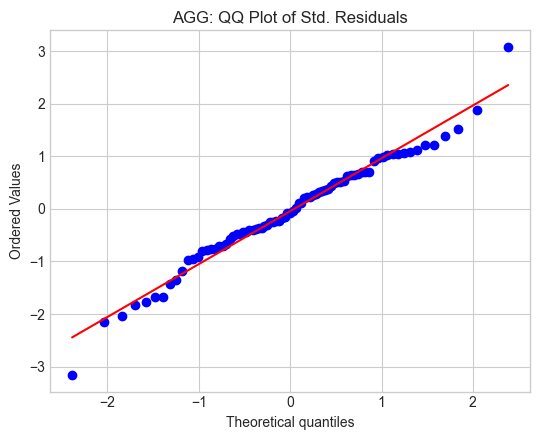

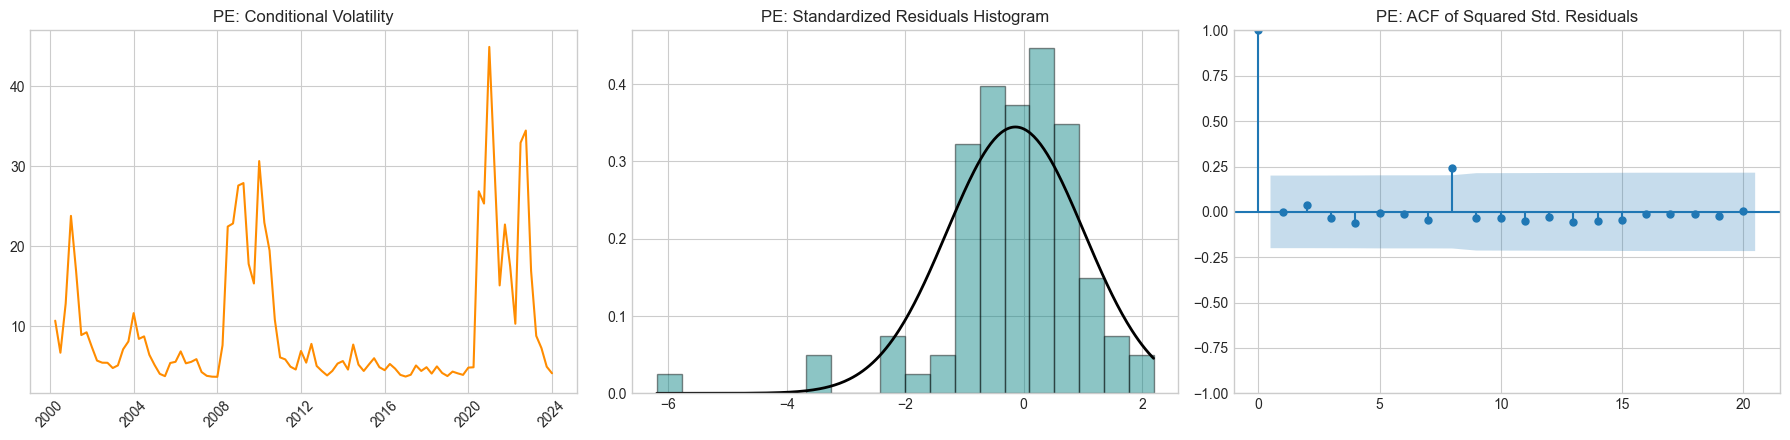

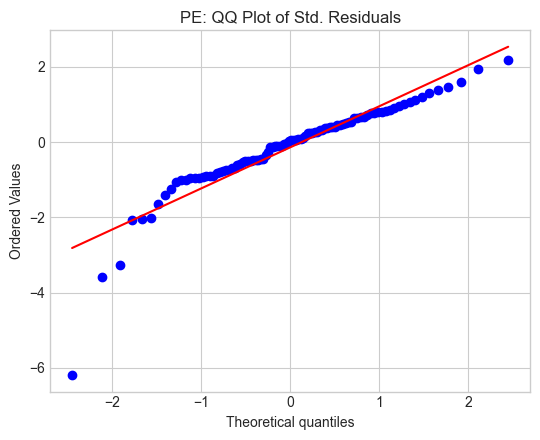

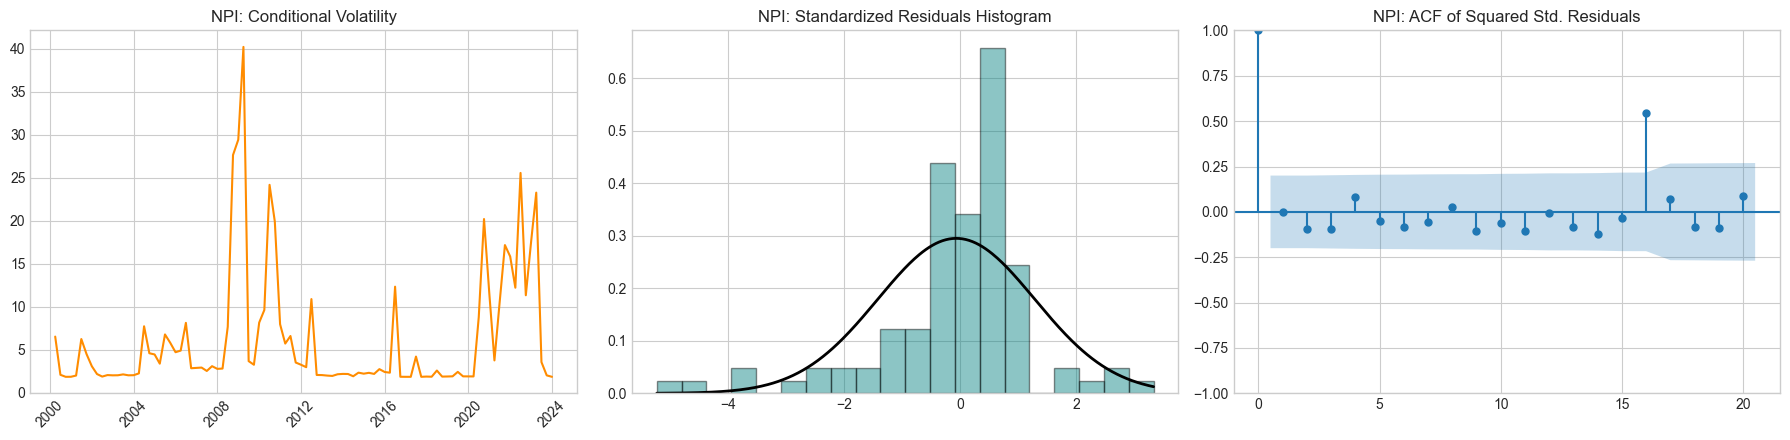

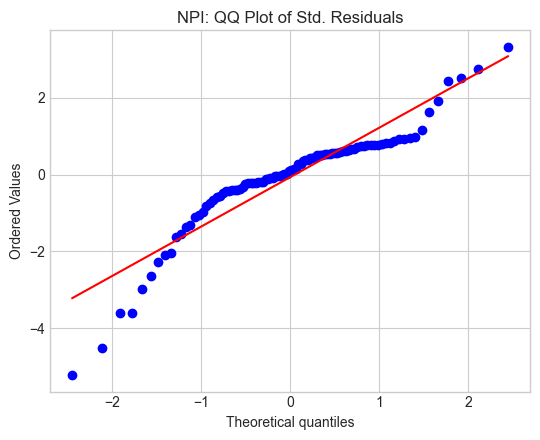

In [ ]:
def plot_garch_diagnostics(all_garch):
    for asset, payload in all_garch.items():
        res = payload['res']

        fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

        # Conditional volatility
        axes[0].plot(res.conditional_volatility.index, res.conditional_volatility.values, color='darkorange')
        axes[0].set_title(f'{asset}: Conditional Volatility')
        axes[0].tick_params(axis='x', rotation=45)

        # Standardized residual histogram
        std_resid = res.std_resid.dropna()
        axes[0].hist(std_resid, bins=PLOT_BINS, density=True, alpha=0.45, color='teal', edgecolor='black')
        xgrid = np.linspace(std_resid.min(), std_resid.max(), 300)
        axes[1].plot(xgrid, norm.pdf(xgrid, np.mean(std_resid), np.std(std_resid, ddof=1)), color='black', lw=2)
        axes[1].set_title(f'{asset}: Standardized Residuals Histogram')

        # ACF of squared standardized residuals
        plot_acf((std_resid ** 2), lags=min(STD_RESID_ACF_MAX_LAGS, len(std_resid) // 3), ax=axes[2])
        axes[2].set_title(f'{asset}: ACF of Squared Std. Residuals')

        plt.tight_layout()
        plt.show()

        # QQ plot in a separate figure for clarity
        fig, ax = plt.subplots(1, 1, figsize=(5.5, 4.5))
        probplot(std_resid, dist='norm', plot=ax)
        ax.set_title(f'{asset}: QQ Plot of Std. Residuals')
        plt.tight_layout()
        plt.show()


plot_garch_diagnostics(all_garch)


**Overall Takeaways**
- All four assets deviate from a pure Gaussian assumption; heavy-tailed models (t or stable) fit better.
- Under a unified `GARCH(1,1)` specification, volatility clustering is present across assets.
- `SPY/PE/NPI` show persistence close to 1, implying slow volatility decay after shocks; `AGG` is relatively more stable.

**Distribution Fit (AIC/BIC)**
- `SPY`: `stable` is best (AIC 680.728), but the gap vs normal/t is not large.
- `AGG`: `t` is best (AIC 367.127), only moderately better than normal.
- `PE`: `t` clearly beats normal (719.848 vs 761.794), indicating stronger tail risk.
- `NPI`: `t` clearly beats normal (633.536 vs 704.211), also indicating pronounced heavy tails.

**GARCH(1,1) Interpretation**
- All assets are estimated with the same `GARCH(1,1)` model.
- Persistence `alpha + beta`:
  - `SPY ≈ 1.000`
  - `AGG ≈ 0.925`
  - `PE ≈ 1.000`
  - `NPI ≈ 1.000`
- Implication:
  - `SPY/PE/NPI`: high-volatility regimes tend to persist.
  - `AGG`: shocks mean-revert faster and it behaves more like a stabilizer.
- t degrees of freedom `nu` (smaller means heavier tails):
  - `NPI 3.846`, `PE 4.525`, `SPY 5.625`, `AGG 7.771`
  - Tail-heaviness ranking: `NPI ≈ PE > SPY > AGG`.

**Portfolio / Risk Management Implication**
- A normal + constant-variance framework is likely inadequate.
- The evidence supports heavy-tailed marginals plus time-varying volatility modeling.
- For allocation and risk budgeting, `PE` and `NPI` require stronger tail-risk buffers, while `AGG` can play a stabilizing role.
